Jarak dari A ke D: 4
Jalur : A->B->C->D


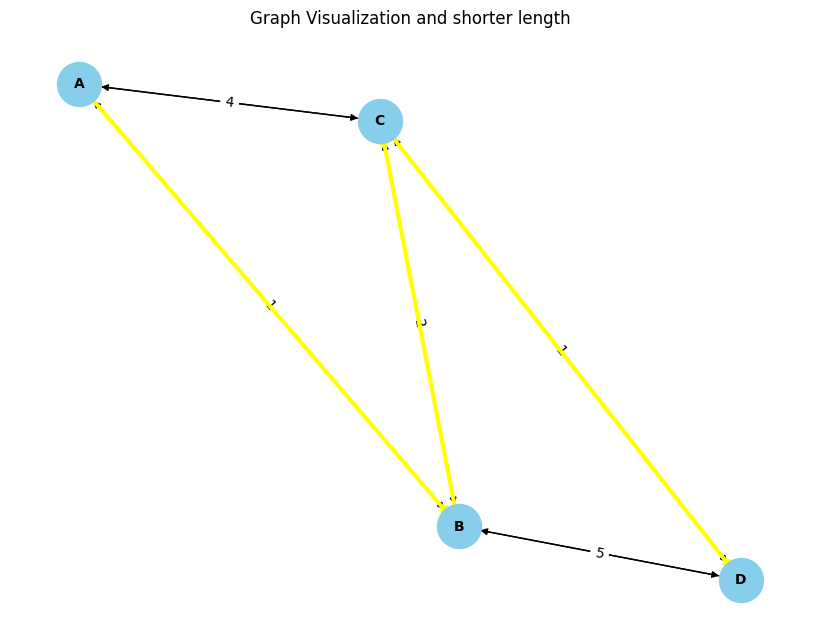

In [1]:
# Perintah untuk meginstal networkx dan matplotlib
# Fungsi untuk memanipulasi dan manmpilkan visualisasi graf
!pip install networkx matplotlib

# Modul untuk mengindikasikan prioritas antrian dalam graf
import heapq
# Modul untuk mengelola graf dinotasikan sebagai nx
import networkx as nx
# Modul untuk membuat grafik dinotasikan sebagai plt
import matplotlib.pyplot as plt


# Mendeklarasikan fungsi djikstra dengan path
# Dalam graf dan start sebagai simpul awal
def dijkstra_with_paths(graph, start):
  # Mengindikasikan dictionary jarak yang belum diketahui
    distances = {node: float('inf') for node in graph}
  # Mengindikasikan jarak dari node awal bernilai 0
    distances[start] = 0
  # Mengindikasikan node awal dalam jalur terpendek
    previous_nodes = {node: None for node in graph}
  # Mengindikasikan antrian prioritas yang berisi jarak dan node awal
    priority_queue = [(0, start)]

  # Fungsi perulangan yang terus berjalan selama antrian masih terisi
    while priority_queue:
    # Mengindikasikan pengambilan node jarak terkecil dari antrian
      current_distance, current_node = heapq.heappop(priority_queue)
    # Fungsi perulangan untuk menelusuri node tetangga
      for neighbor, weight in graph[current_node].items():
      # Mengindikasikan perhitungan jarak baru ke tetangga
        distance = current_distance + weight
      # Fungsi untuk memeriksa jalur terpendek
        if distance < distances[neighbor]:
        # Memperbarui jarak terpdendek dengan tetangga
          distances[neighbor] = distance
        # Menyimpan node sebelumnya untuk membentuk jalur terpendek
          previous_nodes[neighbor] = current_node
        # Memasukkan node dalam antrian pada jarak terpendek
          heapq.heappush(priority_queue, (distance, neighbor))
  # Mengembalikan seluruh jarak dalam node sebelumnya
    return distances, previous_nodes

# Mendeklarasikan jarak terpendek dari node utama
def get_path(previous_nodes, target):
    path = [] # Menyimpan jalur dalam list

  # Fungsi perulangan yang terus berjalan
  # Menelusuri node target sampai node awal
    while target is not None:
    # Menyisipkan node baru di depan
      path.insert(0, target)
    # Mengindikasikan target sebagai node sebelumnya
      target = previous_nodes[target]
    # Mengembalikan jalur secara lengkap
    return path


# Mendeklarasikan fungsi untuk menampilkan graf
def visualize_graph(graph, path = None):
  # Mengindikasikan objek graf beararah
    G = nx.DiGraph()

  # Fungsi perulangan untuk menelusuri seluruh node dalam graph
    for node in graph:
      # Fungsi perulangan untuk menelusuri seluruh tetangga node
        for neighbor, weight in graph[node].items():
        # Menambahkan edge garis dalam graf
          G.add_edge(node, neighbor, weight=weight)
    # Menentukan posisi nodes
    pos = nx.spring_layout(G)
    # Mengambil bobot dalam edge
    edge_labels = nx.get_edge_attributes(G, 'weight')

    # Membentuk area gambar dalam ukuran 8*6
    plt.figure(figsize=(8, 6))
    # Menampilkan gambar graf sesuai ketentuan
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1000, font_size=10, font_weight='bold', arrows=True)
    # Menampilkan bobot dalam setiap edge
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Fungsi kondisi menampilkan jalur yang diinginkan
    if path and len(path) > 1:
      # Mengubah list node dalam bentuk dictionary
        path_edges = list(zip(path, path[1:]))
      # Menampilkan gambar visual dengan garis kuning dan ketebalan 3
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='yellow', width=3)

  # Mengindikaskan judul dari grafik yang ditampilkan
    plt.title("Graph Visualization and shorter length")
  # Menyembunyikan sumbu koordinat
    plt.axis('off')
  # Menampilkan hasil visualisasi
    plt.show()


# Eksekusi implementasi code dari graf
graph = {
    'A': {'B': 1, 'C': 4},
    'B': {'A': 1, 'C': 2, 'D': 5},
    'C': {'A': 4, 'B': 2, 'D': 1},
    'D': {'B': 5, 'C': 1}
}

# Mengindikasikan node awal
start_node = 'A'
# Mengindikasikan node akhir
end_node = 'D'
# Menjalankan algoritma djikstra dari node awal
distances, previous_nodes = dijkstra_with_paths(graph, start_node)

# Mengindikasikan jarak terpendek dari node
shortest_path = get_path(previous_nodes, end_node)
# Menampilkan nilai jarak dari node awal ke node akhir
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
# Menampilkan garis jalur dari node awal ke akhir
print(f"Jalur : {'->'.join(shortest_path)}")

# Menampilkan visualisasi gambar dalam jalur terpendek
visualize_graph(graph, path=shortest_path)